In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 32

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

In [4]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr

mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]
particleState = wcstateToState(particles)
particleStateLR = wcstateToState(particlesLR)

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particlesLR, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)


neighborhoodLR, sparseNeighborhoodLR_ = buildNeighborhood(particlesLR, particles, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighborsLR = computeNeighborhoodStates(particleStateLR, sparseNeighborhoodLR_, mode_str, kernel, kernel, True, False, False)
numNeighborsLR = coo_to_csr(neighborsLR.neighbors).rowEntries
# particleStateLR.densities = computeDensity(particleStateLR, kernel, neighborsLR.get('noghost'), SupportScheme.Gather, config)

print('Number of neighbors:', numNeighbors.shape, numNeighbors)
print('Number of neighbors LR:', numNeighborsLR.shape, numNeighborsLR)

Number of neighbors: torch.Size([1024]) tensor([52, 52, 52,  ..., 52, 52, 52], device='cuda:0')
Number of neighbors LR: torch.Size([256]) tensor([208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
    

In [5]:
# particleState = wcstateToState(particles)
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

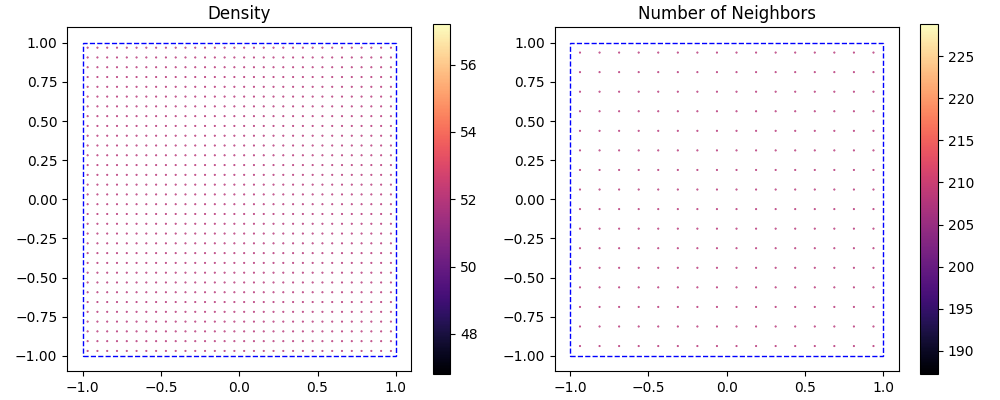

In [6]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = 0.25, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleStateLR, config['domain'], numNeighborsLR,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = 0.25, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [7]:
from ml import *

In [8]:
print(neighbors)

NeighborhoodStates(neighbors=SparseNeighborhood(row=tensor([   0,    0,    0,  ..., 1023, 1023, 1023], device='cuda:0'), col=tensor([207, 221, 222,  ...,  33,  34,  48], device='cuda:0'), numRows=1024, numCols=256, points_a=PointCloud(positions=tensor([[-0.9688, -0.9688],
        [-0.9688, -0.9062],
        [-0.9688, -0.8438],
        ...,
        [ 0.9688,  0.8438],
        [ 0.9688,  0.9062],
        [ 0.9688,  0.9688]], device='cuda:0'), supports=tensor([0.2500, 0.2500, 0.2500,  ..., 0.2500, 0.2500, 0.2500], device='cuda:0')), points_b=PointCloud(positions=tensor([[-0.9375, -0.9375],
        [-0.9375, -0.8125],
        [-0.9375, -0.6875],
        [-0.9375, -0.5625],
        [-0.9375, -0.4375],
        [-0.9375, -0.3125],
        [-0.9375, -0.1875],
        [-0.9375, -0.0625],
        [-0.9375,  0.0625],
        [-0.9375,  0.1875],
        [-0.9375,  0.3125],
        [-0.9375,  0.4375],
        [-0.9375,  0.5625],
        [-0.9375,  0.6875],
        [-0.9375,  0.8125],
        [-0.93

In [9]:
inputFeatures = torch.cat([
    particleState.velocities,
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

inputFeaturesLR = torch.cat([
    particleStateLR.velocities,
    torch.ones_like(particleStateLR.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = particleState.densities.to(device)[:, None]  # ground truth densities

In [10]:
latentSpaceSize = 64
hiddenMLPSize = 128
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [11]:
inputEncoder = buildMLPwDict({
 'inputFeatures': inputFeatures.shape[1],
 'output' : 64,
 'activation': 'celu',
 'layout': [hiddenMLPSize] * inputEncoderLayers,
 'norm': False,
 'bias': False,
}
).to(device)

numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
print(f'Number of parameters in input encoder: {numberOfParameters}')

for i, layer in enumerate(inputEncoder):
    print(f'Layer {i}: {layer}')

encodedInput = inputEncoder(inputFeatures)
encodedInputLR = inputEncoder(inputFeaturesLR)

Number of parameters in input encoder: 192
Layer 0: Linear(in_features=3, out_features=64, bias=False)


In [12]:
from diffSPH.neighborhood import computeSparseDistanceTensor

filteredNeighborhood = neighbors.neighbors
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood)
sparse_edge_attr = xij_ / h_i[:,None]


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

In [13]:
torch.cuda.empty_cache()

In [14]:
from diffSPH.neighborhood import computeSparseDistanceTensor, SparseNeighborhood

def buildDenseNeighborhood(particleState, domain):
    batch_ids = torch.unique(particleState.batches) if particleState.batches is not None else None
    if batch_ids is not None:
        print(f'Building dense neighborhood for batches: {batch_ids}')
        cumulativeParticles = 0
        rowIndices = []
        colIndices = []
        for batch_id in batch_ids:
            batch_mask = particleState.batches == batch_id
            numPtcls = particleState.positions[batch_mask].shape[0]
            indices = torch.arange(numPtcls).reshape(-1, numPtcls).repeat(numPtcls, 1).to(device)
            rowIndices.append(indices.t().reshape(-1) + cumulativeParticles)
            colIndices.append(indices.reshape(-1) + cumulativeParticles)

            cumulativeParticles += numPtcls

        rowIndices = torch.cat(rowIndices)
        colIndices = torch.cat(colIndices)

        denseNeighborhood = SparseNeighborhood(
            row = rowIndices,
            col = colIndices,
            numRows = cumulativeParticles,
            numCols = cumulativeParticles,
            
            points_a = PointCloud(
                positions = particleState.positions[batch_mask],
                supports = particleState.supports[batch_mask],
            ),
            points_b = PointCloud(
                positions = particleState.positions[batch_mask],
                supports = particleState.supports[batch_mask],
            ),
            
            domain = domain,
        )

        return denseNeighborhood

    else:
        numPtcls = particleState.positions.shape[0]
        indices = torch.arange(numPtcls).reshape(-1, numPtcls).repeat(numPtcls, 1).to(device)
        rowIndices = indices.t().reshape(-1)
        colIndices = indices.reshape(-1)

        denseNeighborhood = SparseNeighborhood(
            row = rowIndices,
            col = colIndices,
            numRows = nx**2,
            numCols = nx**2,
            
            points_a = PointCloud(
                positions = particleState.positions,
                supports = particleState.supports,
            ),
            points_b = PointCloud(
                positions = particleState.positions,
                supports = particleState.supports,
            ),
            
            domain = domain,
        )

        return denseNeighborhood

def buildSparseNeighborhood(particleState, neighbors):
    filteredNeighborhood = filterNeighborhoodByKind(particleState, neighbors.neighbors, 'noghost')
    return filteredNeighborhood

In [15]:
def softmax(attentionScoresSparse, sparse_values, rows, cols, sparse_indices): #batch_size, multiHeads, num_edges, sparse_values, cols, num_nodes_neighbor):
    batch_size, multiHeads, num_nodes_neighbor, num_nodes_current = attentionScoresSparse.shape
    # sparse_values = attentionScoresSparse.values()
    # cols = sparse_indices[1]  # Assuming the second index is the column indices
    num_edges = sparse_values.shape[0]

    # if self.verbose:
        # print('attentionScores shape:', attentionScores.shape)
    # attention_weights_sparse = torch.sparse.softmax(attentionScoresSparse, dim=2)

    # Let's work with a flattened view for easier scattering
    # Shape: [B * H, num_edges]
    scores = sparse_values.reshape(batch_size * multiHeads, -1)

    # The 'cols' index needs to be broadcast to match the new shape
    # It will guide the grouping for every head in every batch item
    index = cols.expand_as(scores)

    print(f'===============================================================')
    print(f'Computing normalized attention weights for {batch_size} batches, {multiHeads} heads, {num_edges} edges')
    print(f'Index shape: {index.shape}, Scores shape: {scores.shape}')

    # 1. Subtract max for numerical stability (a standard softmax trick)
    # We need to find the max score for each destination node group
    # 'scatter_max' is not native, so we use a dense intermediate for this step.
    # It's an acceptable tradeoff as it's not on a huge tensor.
    alpha_max = torch.zeros(batch_size * multiHeads, num_nodes_neighbor, device=scores.device).scatter_reduce_(
        1, index, scores, reduce="amax", include_self=False
    )
    print(f'Alpha max shape: {alpha_max.shape} [ {alpha_max.numel()} elements ]')

    # Now gather the max value for each edge
    scores_sub = scores - alpha_max.gather(1, index)
    print(f'Scores shape after subtracting max: {scores_sub.shape} [ {scores_sub.numel()} elements ]')

    # 2. Exponentiate the scores
    exp_scores = torch.exp(scores_sub)
    print(f'Exponentiated scores shape: {exp_scores.shape} [ {exp_scores.numel()} elements ]')

    # 3. Sum the exponentiated scores for each destination node group
    # This is the denominator of the softmax
    exp_sum = torch.zeros(batch_size * multiHeads, num_nodes_neighbor, device=scores.device).scatter_add_(
        1, index, exp_scores
    )
    print(f'Exponentiated sum shape: {exp_sum.shape} [ {exp_sum.numel()} elements ]')
    # Add a small epsilon to prevent division by zero
    exp_sum = exp_sum + 1e-10
    print(f'Exponentiated sum after adding epsilon: {exp_sum.shape} [ {exp_sum.numel()} elements ]')

    # 4. Divide each score by its group's sum to get the final weights
    normalized_weights_flat = exp_scores / exp_sum.gather(1, index)
    print(f'Normalized weights shape: {normalized_weights_flat.shape} [ {normalized_weights_flat.numel()} elements ]')

    attention_weights_sparse = torch.sparse_coo_tensor(
        indices=sparse_indices,
        values=normalized_weights_flat.flatten(),
        size=attentionScoresSparse.shape
    )
    return attention_weights_sparse, normalized_weights_flat

In [48]:
from typing import Union, Tuple
class TransformerLayer(torch.nn.Module):
    def __init__(self, input_dim, transformer_features, edgeFeatureSize, multi_heads, 
                 edge_bias = False, edge_gating = False,
                 additive_bias = True, verbose = False,
                 activation = 'celu', ffnHiddenLayers = 1, ffnHiddenSize = 0,
                 attentionOp = 'dot', attentionOpIncludeEdge = False):
        super(TransformerLayer, self).__init__()
        if verbose:
            print(f'Initializing TransformerLayer with input_dim={input_dim}, transformer_features={transformer_features}, edgeFeatureSize={edgeFeatureSize}, multi_heads={multi_heads}, edge_bias={edge_bias}, edge_gating={edge_gating}, additive_bias={additive_bias}')

        if verbose:
            print(f'===============================================================')
            print(f'Building linear projections for Q, K, V')

        self.W_Q = torch.nn.Linear(input_dim, transformer_features * multi_heads, bias=False)
        self.W_K = torch.nn.Linear(input_dim, transformer_features * multi_heads, bias=False)
        self.W_V = torch.nn.Linear(input_dim, transformer_features * multi_heads, bias=False)
        if verbose:
            print(f'\tW_Q shape: {self.W_Q.weight.shape}, W_K shape: {self.W_K.weight.shape}, W_V shape: {self.W_V.weight.shape}')

        if verbose:
            print(f'===============================================================')
            print(f'Building edge bias and gating projections')
        if edge_bias:
            self.W_E = torch.nn.Linear(edgeFeatureSize, multi_heads).to(device)
            if verbose:
                print(f'\tUsing edge bias with W_E shape: {self.W_E.weight.shape}')
        else:
            self.W_E = None
            
        # Edge gating is optional and can be used to gate the value matrix with edge features
        if edge_gating:
            self.W_E_gate = torch.nn.Linear(edgeFeatureSize, multi_heads * transformer_features).to(device)
            if verbose:
                print(f'\tUsing edge gating with W_E_gate shape: {self.W_E_gate.weight.shape}')
        else:
            self.W_E_gate = None

        if verbose:
            print(f'===============================================================')
            print(f'Building output projection steps')
        self.activation = activation if isinstance(activation, torch.nn.Module) else getActivationLayer(activation)
        self.W_O = torch.nn.Linear(transformer_features * multi_heads, input_dim, bias=False)
        self.layer_norm1 = torch.nn.LayerNorm(input_dim)
        self.layer_norm2 = torch.nn.LayerNorm(input_dim)

        if verbose:
            print(f'\tW_O shape: {self.W_O.weight.shape}')

        self.hiddenLayers = ffnHiddenLayers
        self.ffnHiddenSize = ffnHiddenSize if ffnHiddenSize > 0 else input_dim * 4

        if verbose:
            print(f'===============================================================')
            print(f'Building Feedforward Network (FFN) with {self.hiddenLayers} hidden layers and hidden size {self.ffnHiddenSize}')

        # Build FFN with configurable number of hidden layers and hidden size
        layers = []
        in_dim = input_dim
        for i in range(self.hiddenLayers):
            layers.append(torch.nn.Linear(in_dim, self.ffnHiddenSize))
            layers.append(self.activation)
            in_dim = self.ffnHiddenSize
        layers.append(torch.nn.Linear(in_dim, input_dim))
        self.ffn = torch.nn.Sequential(*layers)

        if verbose:
            print(f'\tFFN: {self.ffn}')

        self.multiHeads = multi_heads
        self.transformerFeatures = transformer_features
        self.edgeFeatureSize = edgeFeatureSize

        self.edgeBias = edge_bias
        self.edgeGating = edge_gating
        self.additiveBias = additive_bias
        self.verbose = verbose

        self.attentionOp = attentionOp  # 'dot' or 'GAT' or 'MLP'
        self.attentionOpIncludeEdge = attentionOpIncludeEdge

        inputSize = 2 * transformer_features
        if self.attentionOpIncludeEdge:
            inputSize += edgeFeatureSize  # Include edge features in GAT attention

        if self.attentionOp == 'GAT':
            # Multi-head GAT attention: one parameter per head
            self.W_a = torch.nn.Linear(inputSize, 1, bias=False).to(device)
            # The LeakyReLU activation, with the negative slope commonly used in GAT.
            self.leaky_relu = nn.LeakyReLU(0.2)
        elif self.attentionOp == 'MLP':
            hiddenSize = transformer_features * multi_heads
            hiddenLayers = ffnHiddenLayers
            layers = []
            in_dim = inputSize
            for i in range(hiddenLayers):
                layers.append(torch.nn.Linear(in_dim, hiddenSize))
                layers.append(self.activation)
                in_dim = hiddenSize
            layers.append(torch.nn.Linear(in_dim, inputSize))
            self.W_a = torch.nn.Sequential(*layers)

            # The LeakyReLU activation, with the negative slope commonly used in GAT.
            self.leaky_relu = nn.LeakyReLU(0.2)
        else:
            self.W_a = None  # For 'dot' attention, no additional weights are needed

        if verbose:
            print(f'===============================================================')
            print(f'TransformerLayer initialized with input_dim={input_dim}, transformer_features={transformer_features}, edgeFeatureSize={edgeFeatureSize}, multi_heads={multi_heads}, edge_bias={edge_bias}, edge_gating={edge_gating}, additive_bias={additive_bias}')

    def forward(self, inputTokens_: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]], inputEdges, edgeIndices):
        if isinstance(inputTokens_, tuple):
            inputTokensCurrent, inputTokensNeighbor = inputTokens_
        else:
            inputTokensCurrent = inputTokensNeighbor = inputTokens_  # No row information if not provided
        batch_size, num_nodes_current, latentSpaceSize = inputTokensCurrent.shape
        # because of how the sparsity works we cannot split any operations across edges based on batches as each batch will have a different number of edges
        # so we assume that the batch size is 1 for the current implementation
        # if you want to support multiple batches, you need to modify the code to handle that
        batch_size_edges = 1
        num_nodes_neighbor = inputTokensNeighbor.shape[1]
        # Multi-Head Attention with Edge Information
        if self.verbose:
            print(f'===============================================================')
            print(f'Input tokens shape: {inputTokensCurrent.shape}')
            if inputEdges is not None:
                print(f'Input edges shape: {inputEdges.shape}')
            else:
                print('No edge features provided')

            if edgeIndices is not None:
                print(f'Edge indices shape: {edgeIndices.shape}')
            else:
                print('No edge indices provided')
                raise ValueError('Edge indices must be provided for sparse neighborhoods')
            
        rows = edgeIndices[0]
        cols = edgeIndices[1]

        if self.verbose:
            print(f'===============================================================')

        Q = self.W_Q(inputTokensCurrent)
        K = self.W_K(inputTokensNeighbor)
        V = self.W_V(inputTokensNeighbor)

        Q = Q.view(batch_size, Q.shape[1], self.multiHeads, self.transformerFeatures).permute(0, 2, 1, 3)
        K = K.view(batch_size, K.shape[1], self.multiHeads, self.transformerFeatures).permute(0, 2, 1, 3)
        V = V.view(batch_size, V.shape[1], self.multiHeads, self.transformerFeatures).permute(0, 2, 1, 3)

        if self.verbose:
            print('Q shape:', Q.shape)
            print('K shape:', K.shape)
            print('V shape:', V.shape)

        # Scale Q by sqrt(d_k)
        # This is a common practice in Transformer architectures to stabilize training
        # and improve convergence.
        # The scaling factor is the square root of the dimension of the key vectors (d_k).
        # It helps to prevent the dot product from growing too large, which can lead to
        # very small gradients and slow down training.
        # This scaling is applied before the softmax operation in the attention mechanism.
        # It ensures that the attention scores are not too large, which can lead to numerical instability.
        # In this case, d_k is equal to transformerFeatures.
        # Therefore, we scale Q by the square root of transformerFeatures.
        Q = Q / (self.transformerFeatures ** 0.5)  # Scale by sqrt(d_k)

        # if self.edgeBias:
        # else:
        # For a dense neighborhood we can run a matmul directly
        # attentionScores = torch.matmul(Q, K.transpose(-2, -1))

        # Attention scores shape: [batch_size, multiHeads, num_nodes, num_nodes]
        # print(f'===============================================================')
        # print('attentionScores shape:', attentionScores.shape)
        # For a sparse neighborhood we need to use the edge indices
        if self.verbose:
            print(f'===============================================================')
            print('Using sparse neighborhood for attention scores')

        # Q has shape [batch_size, multiHeads, num_nodes, transformerFeatures]
        # K has shape [batch_size, multiHeads, num_nodes, transformerFeatures]
        # We need to compute the attention scores using the edge indices
        # This is done by selecting the rows and columns from Q and K based on edgeIndices
        # rows and cols are the indices of the edges in the sparse neighborhood
        # However, the edgeIndices are for the flattened versions of Q and K
        Q_flat = Q.permute(0, 2, 1, 3).reshape(batch_size * num_nodes_current, self.multiHeads, self.transformerFeatures)
        K_flat = K.permute(0, 2, 1, 3).reshape(batch_size * num_nodes_neighbor, self.multiHeads, self.transformerFeatures)
        # Q_flat = Q.reshape(batch_size * self.multiHeads, num_nodes, self.transformerFeatures)
        # K_flat = K.reshape(batch_size * self.multiHeads, num_nodes, self.transformerFeatures)
        if self.verbose:
            print(f'Q_flat shape: {Q_flat.shape}, K_flat shape: {K_flat.shape}')
            print(f'Rows: {rows}, Cols: {cols}')

        # Now we can index the query matrices using the rows and the key matrices using the cols
        # This will give us the correct rows and columns for the attention scores
        if self.verbose:
            print(f'Edge indices: {edgeIndices}')
            print(f'Rows: {rows}, Cols: {cols}')

        # Gather the vectors for each edge
        # Q_i are the queries for the destination nodes of each edge
        # K_j are the keys for the source nodes of each edge

        # Q has shape [batch_size, multiHeads, num_nodes_current, transformerFeatures]
        # K has shape [batch_size, multiHeads, num_nodes_neighbor, transformerFeatures]
        # because of the sparse neighborhood we need to unify the batch size and num_nodes entries
        # Q_i will then have shape [multiHeads, num_edges, transformerFeatures]
        # K_j will have shape [multiHeads, num_edges, transformerFeatures]
        # where num_edges is the number of edges in the sparse neighborhood

        # Q_unified will have shape [multiHeads, batch_size * num_nodes_current, transformerFeatures]
        # K_unified will have shape [multiHeads, batch_size * num_nodes_neighbor, transformerFeatures]
        Q_unified = Q.permute(1, 0, 2, 3).reshape(self.multiHeads, batch_size * num_nodes_current, self.transformerFeatures)
        K_unified = K.permute(1, 0, 2, 3).reshape(self.multiHeads, batch_size * num_nodes_neighbor, self.transformerFeatures)


        Q_i = Q_unified[:, rows, :] # Shape: [B, H, num_edges, F]
        K_j = K_unified[:, cols, :] # Shape: [B, H, num_edges, F]


        # Q_i_dense = Q_i.view(batch_size, self.multiHeads, num_nodes, num_nodes, self.transformerFeatures)
        # K_j_dense = K_j.view(batch_size, self.multiHeads, num_nodes, num_nodes, self.transformerFeatures)

        # print(f'Q_i_dense shape: {Q_i_dense.shape}, K_j_dense shape: {K_j_dense.shape}')
        # print(f'Q_i shape: {Q_i.shape}, K_j shape: {K_j.shape}')

        # if torch.any(torch.logical_not(torch.isclose(Q_i_dense, Q))) or torch.any(torch.logical_not(torch.isclose(K_j_dense, K))):
        #     print('Q_i or K_j mismatch with Q or K!')
        #     print('Q_i:', Q_i_dense)
        #     print('Q:', Q)
        #     print('K_j:', K_j_dense)
        #     print('K:', K)
        #     raise ValueError('Q_i or K_j mismatch with Q or K!')

        if self.verbose:
            print(f'Q_i shape: {Q_i.shape}, K_j shape: {K_j.shape}')
            print(f'Rows: {rows.shape}, Cols: {cols.shape}')
            print(f'Rows: {rows}, Cols: {cols}')

        if self.verbose:
            print(f'Edge indices shape: {edgeIndices.shape}')
            print(f'Rows: {rows}, Cols: {cols}')

        # sparseAttentionValues = torch.einsum('hij,hki->hi', Q_i, K_j.transpose(-2, -1))
        

        sparseAttentionValuesRef = (Q_i * K_j).sum(dim=-1) # / (self.transformerFeatures**0.5)
        print(f'sparseAttentionValuesRef shape: {sparseAttentionValuesRef.shape}, should be [B, H, num_edges]')
        # Normal dot product attention scores
        if self.attentionOp == 'dot':
            if self.verbose:
                print(f'Using dot product attention scores')
            sparseAttentionValues = (Q_i * K_j).sum(dim=-1)
            print(f'dot product attention scores shape: {sparseAttentionValues.shape}, should be {sparseAttentionValuesRef.shape}')  # Shape: [B, H, num_edges]
        elif self.attentionOp == 'GAT':
            if self.verbose:
                print(f'Using GAT attention scores')
            # GAT attention scores: W_a(Q_i || K_j)
            # Concatenate Q_i and K_j along the last dimension
            if not self.attentionOpIncludeEdge:
                combined = torch.cat([Q_i, K_j], dim=-1)  # Shape: [B, H, num_edges, 2*F]
            else:
                # input edges has shape [num_edges, edgeFeatureSize]
                # We need to expand it to match the batch size and multi-heads
                expanded_inputEdges = inputEdges.view(batch_size_edges, 1, Q_i.shape[2], -1).expand(batch_size_edges, self.multiHeads, -1, -1)  # Shape: [B, H, edgeFeatureSize]
                print(f'Input edges shape: {inputEdges.shape}, edgeFeatureSize: {self.edgeFeatureSize}')
                print(f'Q_i shape: {Q_i.shape}, K_j shape: {K_j.shape}')
                print(f'Expanded input edges shape: {expanded_inputEdges.shape}')

                combined = torch.cat([Q_i, K_j, expanded_inputEdges], dim=-1)  # Shape: [B, H, num_edges, 2*F + edgeFeatureSize]
            sparseAttentionValues = self.W_a(combined)  # Shape: [B, H, num_edges, 1]
            sparseAttentionValues = self.leaky_relu(sparseAttentionValues).squeeze(-1)  # Shape: [B, H, num_edges]
            print(f'GAT attention scores shape: {sparseAttentionValues.shape}, should be {sparseAttentionValuesRef.shape}')  # Shape: [B, H, num_edges]
        elif self.attentionOp == 'MLP':
            if self.verbose:
                print(f'Using MLP attention scores')
            expanded_inputEdges = inputEdges.view(batch_size_edges, 1, Q_i.shape[2], -1).expand(batch_size_edges, self.multiHeads, -1, -1)  # Shape: [B, H, edgeFeatureSize]
            if not self.attentionOpIncludeEdge:
                combined = torch.cat([Q_i, K_j], dim=-1)  # Shape: [B, H, num_edges, 2*F]
            else:
                combined = torch.cat([Q_i, K_j, expanded_inputEdges], dim=-1)  # Shape: [B, H, num_edges, 2*F + edgeFeatureSize]
            sparseAttentionValues = self.W_a(combined).squeeze(-1)  # Shape: [B, H, num_edges]
            sparseAttentionValues = self.leaky_relu(sparseAttentionValues)  # Apply activation
            print(f'MLP attention scores shape: {sparseAttentionValues.shape}, should be {sparseAttentionValuesRef.shape}')  # Shape: [B, H, num_edges]
        else:
            raise ValueError(f'Unknown attention operation: {self.attentionOp}')
        



        sparse_values = sparseAttentionValues.flatten()
        size = (batch_size_edges, self.multiHeads, num_nodes_current * batch_size, num_nodes_neighbor * batch_size)


        print(f'sparseAttentionValues shape: {sparseAttentionValues.shape}')
        
        # denseAttentionValues = sparseAttentionValues.view(batch_size, self.multiHeads, num_nodes, num_nodes)
        # if torch.any(torch.logical_not(torch.isclose(denseAttentionValues, attentionScores))):
        #     print('Attention scores mismatch! ')
        #     print('denseAttentionValues:', denseAttentionValues)
        #     print('attentionScores:', attentionScores)
        #     raise ValueError('Attention scores mismatch! ')
        num_edges = edgeIndices.shape[1]

        # 1. Create indices for the batch dimension (b)
        # Each of the H*num_edges scores in a batch item gets the same batch index
        b_idx = torch.arange(batch_size_edges, device=Q.device).repeat_interleave(self.multiHeads * num_edges)

        # 2. Create indices for the head dimension (h)
        # Within each batch item, the indices 0..H-1 repeat for each edge
        h_idx = torch.arange(self.multiHeads, device=Q.device).repeat_interleave(num_edges).repeat(batch_size_edges)

        # 3. Repeat the edge indices for each batch and head
        # Destination nodes (i)
        i_idx = cols.repeat(batch_size_edges * self.multiHeads)
        # Source nodes (j)
        j_idx = rows.repeat(batch_size_edges * self.multiHeads)

        # 4. Stack them all together to create the final sparse indices
        # Shape will be [4, B * H * num_edges]
        sparse_indices = torch.stack([b_idx, h_idx, i_idx, j_idx], dim=0)

        if self.edgeBias:
            if self.verbose:
                print(f'===============================================================')
                print('Using edge bias for attention scores')
            edge_bias = self.W_E(inputEdges).reshape(1, num_edges, self.multiHeads) # shape: [batch, num_edges, multiHeads]
            # print('edge_bias shape:', edge_bias.shape)
            # We need to align the dimensions for broadcasting with attention scores
            edge_bias = edge_bias.permute(0, 2, 1) # shape: [batch, multiHeads, num_edges]

            if self.verbose:
                print(f'Edge bias shape after permute: {edge_bias.shape}')
                print(f'Attention scores shape before edge bias: {Q.shape} x {K.transpose(-2, -1).shape}')

            # Compute Edge-aware Attention Scores
            if self.additiveBias:
                sparse_values = sparse_values + edge_bias.flatten()
            else:
                sparse_values = sparse_values * edge_bias.flatten()

        # Create the sparse tensor of raw scores
        attentionScoresSparse = torch.sparse_coo_tensor(
            indices=sparse_indices,
            values=sparse_values,
            size=size
        )

        # if self.edgeBias:
        #     if self.verbose:
        #         print(f'===============================================================')
        #         print('Using edge bias for attention scores')
        #     edge_bias = self.W_E(inputEdges).reshape(1, nx**2, nx**2, self.multiHeads) # shape: [batch, num_nodes, num_nodes, multiHeads]
        #     # print('edge_bias shape:', edge_bias.shape)
        #     # We need to align the dimensions for broadcasting with attention scores
        #     edge_bias = edge_bias.permute(0, 3, 2, 1) # shape: [batch, multiHeads, num_nodes, num_nodes]

        #     if self.verbose:
        #         print(f'Edge bias shape after permute: {edge_bias.shape}')
        #         print(f'Attention scores shape before edge bias: {Q.shape} x {K.transpose(-2, -1).shape}')

        #     # Compute Edge-aware Attention Scores
        #     if self.additiveBias:
        #         attentionScores = attentionScores + edge_bias          

        #     else:
        #         attentionScores = attentionScores * edge_bias


        # attentionScoresSparse = torch.sparse_coo_tensor(
        #     indices=torch.stack([rows, cols]),
        #     values=sparseAttentionValues.flatten(),
        #     size=(batch_size, self.multiHeads, num_nodes, num_nodes)
        # )
        print(f'Attention scores sparse shape: {attentionScoresSparse.shape} [ {attentionScoresSparse._nnz()} non-zero entries   ]')
        # attentionScores = attentionScoresSparse.to_dense().view(batch_size, self.multiHeads, num_nodes, num_nodes)
        attention_weights_sparse, normalized_weights_ = softmax(attentionScoresSparse, sparse_values, rows, cols, sparse_indices)
        normalized_weights_flat = normalized_weights_.flatten()

        # 5. Reshape back to the desired [B, H, num_edges] format
        normalized_weights = normalized_weights_flat.view(batch_size_edges, self.multiHeads, num_edges)


        # attentionScores = torch.nn.functional.softmax(attentionScores, dim=-1)

        # print(f'Attention scores shape after softmax: {attentionScores.shape}')
        print(f'Attention weights sparse shape: {attention_weights_sparse.shape} [ {attention_weights_sparse._nnz()} non-zero entries   ]')
    
        # if torch.any(torch.logical_not(torch.isclose(attentionScores, attention_weights_sparse.to_dense()))):
        #     print('Attention scores mismatch with sparse weights!')
        #     print('attentionScores:', attentionScores)
        #     print('attention_weights_sparse:', attention_weights_sparse.to_dense())
        #     raise ValueError('Attention scores mismatch with sparse weights!')
        

        if self.verbose:
            print(f'===============================================================')
            print('attentionScores shape after softmax:', attentionScoresSparse.shape)
        # if self.edgeGating:
        #     if self.verbose:
        #         print(f'===============================================================')
        #         print('Using edge gating for value matrix')
        #     # ==============================================================================
        #     # --- NEW: Gating the Value matrix with Edge Features ---
        #     # 1. Create a new linear projection for the edge gates
        #     # The output must match the feature dimension of V

        #     # 2. Project edge features and apply sigmoid
        #     # dense_mod_xij shape: [B, N, N, edgeFeatureSize]
        #     edge_gate = self.W_E_gate(inputEdges) # Shape: [B, N, N, H*F]
        #     edge_gate = torch.sigmoid(edge_gate)
        #     if self.verbose:
        #         print(f'Edge gate shape after projection and sigmoid: {edge_gate.shape}')

        #     # 3. Reshape the gate to match the multi-head structure for broadcasting
        #     # New shape: [B, N (query), N (key), H, F] -> [B, H, N (query), N (key), F]
        #     edge_gate = edge_gate.view(batch_size, num_nodes, num_nodes, multiHeads, transformerFeatures)
        #     edge_gate = edge_gate.permute(0, 3, 1, 2, 4)
        #     if self.verbose:
        #         print(f'Edge gate shape after reshape and permute: {edge_gate.shape}')

        #     # 4. Prepare V for gating. We need to align it with the [query, key] structure of the gate
        #     # V shape is [B, H, N (key), F]. We unsqueeze to add a "query" dimension for broadcasting
        #     V_expanded = V.unsqueeze(2) # Shape: [B, H, 1, N (key), F]

        #     # 5. Apply the gate. Broadcasting rules will make this work.
        #     # V_expanded is broadcast across the "query" dimension (dim 2)
        #     # edge_gate is broadcast across the "value feature" dimension (dim 4)
        #     V_gated = V_expanded * edge_gate # Shape: [B, H, N (query), N (key), F]
        #     # print(f'V_gated after gating: {V_gated}')
        #     if self.verbose:
        #         print(f'V_gated shape after gating: {V_gated.shape}')

        #     # 6. Compute the final output using the gated values
        #     # The matmul is now between attentionScores [B,H,N,N] and a gated V
        #     # We need to sum over the "key" dimension. This is no longer a simple matmul.
        #     # We can do it with einsum for clarity or broadcasting + sum.
        #     # attentionScores needs an extra dimension: [B, H, N (query), N (key), 1]
        #     # Then multiply and sum over the key dimension (dim=3)
        #     attentionOutput = (attentionScores.unsqueeze(-1) * V_gated).sum(dim=3)
        #     # Final shape of attentionOutput: [B, H, N (query), F]
        #     # ==============================================================================

        #     # --- Reshape back (this part is now different) ---
        #     # Previous shape was [B, H, N, F]. Now it's [B, H, N (query), F], which is the same.
        #     attentionOutput = attentionOutput.permute(0, 2, 1, 3).contiguous().view(batch_size, num_nodes, -1)
                
        # else:
        # # ==============================================================================
        # # --- Original Attention Output without Edge Gating ---
        # # 1. Compute Edge-aware Attention Output
        # # attentionOutput = torch.matmul(attentionScores, V)
        # # attentionOutput = attentionOutput.permute(0, 2, 1, 3).contiguous().view(batch_size, num_nodes, -1)
        # # ==============================================================================
        #     attentionOutput = torch.matmul(attentionScores, V)
        #     attentionOutput = attentionOutput.permute(0, 2, 1, 3).contiguous().view(batch_size, num_nodes, -1)


        # Get the normalized weights from the sparse tensor
        # normalized_weights = attention_weights_sparse.values() # Shape: [B * H * num_edges]
        normalized_weights = normalized_weights.view(batch_size_edges, self.multiHeads, num_edges)
        print(f'Normalized weights shape: {normalized_weights.shape} [ {normalized_weights.numel()} elements ]')

        V_unified = V.permute(1, 0, 2, 3).reshape(self.multiHeads, batch_size * num_nodes_neighbor, self.transformerFeatures)

        V_j = V_unified[:, cols, :] # Shape: [B, H, num_edges, F]
        print(f'V_j shape: {V_j.shape} [ {V_j.numel()} elements ]')

        messages = V_j  # This is the message vector for each edge

        # Weight the V_j vectors with the normalized attention
        # Add a dimension for broadcasting: weights shape -> [B, H, num_edges, 1]
        if self.edgeGating:
            if self.verbose:
                print(f'===============================================================')
                print('Using edge gating for messages')
            # 3. Project edge features to create the gate
            # W_E_gate is a nn.Linear(edge_feature_dim, self.multiHeads * self.transformerFeatures)
            edge_gate_values = self.W_E_gate(inputEdges) # Shape: [num_edges, H*F]
            edge_gate_values = torch.sigmoid(edge_gate_values)

            # 4. Reshape gate to be compatible with V_j for broadcasting
            # Goal shape: [1, H, num_edges, F]
            edge_gate_values = edge_gate_values.view(
                num_edges, self.multiHeads, self.transformerFeatures
            ) # Shape: [num_edges, H, F]
            edge_gate_values = edge_gate_values.permute(1, 0, 2).unsqueeze(0) # Shape: [1, H, num_edges, F]

            if self.verbose:
                print(f"Shape of V_j to be gated: {V_j.shape}")
                print(f"Shape of sparse edge gate: {edge_gate_values.shape}")

            # 5. Apply the gate to the V_j vectors. Broadcasting handles the batch dim.
            gated_V_j = V_j * edge_gate_values

            # gated_V_j_dense = gated_V_j.view(batch_size, self.multiHeads, num_nodes, num_nodes, self.transformerFeatures)
            # print(f'Gated V_j dense shape: {gated_V_j_dense.shape} | V_gated shape: {V_gated.shape}')

            # if torch.any(torch.logical_not(torch.isclose(gated_V_j_dense, V_gated))):
            #     print('Gated V_j mismatch with V!')
            #     print('gated_V_j:', gated_V_j_dense)
            #     print('V:', V_gated)
            #     raise ValueError('Gated V_j mismatch with V!')

            messages = gated_V_j # Update messages to be the gated version


        final_messages = messages * normalized_weights.unsqueeze(-1)

        # 4. Prepare the components for the hybrid sparse tensor
        # We can reuse the indices from our attention score calculation
        # sparse_indices has shape [4, B * H * num_edges] and maps to [b, h, i, j]
        #
        # The values are now the message vectors. We need to reshape them to match the indices.
        # Shape: [B, H, num_edges, F] -> [B * H * num_edges, F]
        message_values = final_messages.reshape(-1, self.transformerFeatures)

        # The full size of the hybrid tensor: sparse part + dense part
        hybrid_size = (
            batch_size_edges,
            self.multiHeads,
            num_nodes_current * batch_size,  # Number of destination nodes (i)
            num_nodes_neighbor * batch_size,  # Number of source nodes (j)
            self.transformerFeatures  # The dense dimension
        )

        # 5. Create the hybrid sparse tensor representing messages
        sparse_message_tensor = torch.sparse_coo_tensor(
            indices=sparse_indices, # Reuse the indices
            values=message_values,
            size=hybrid_size
        )

        # 6. Sum over the source dimension 'j' (dim=3) to aggregate messages
        # This collapses the j-th dimension, summing all messages for each (b, h, i)
        aggregated_messages_sparse = torch.sparse.sum(sparse_message_tensor, dim=3)

        # 7. Convert the result back to a dense tensor
        # The result has aggregated messages for each node.
        # Shape: [B, H, N, F]
        dense_output = aggregated_messages_sparse.to_dense()

        # ==============================================================================

        # 8. Reshape for the final layers
        # Shape: [1, H, B*N, F] -> [B, N, H*F]
        print(f'===============================================================')
        print('Dense output shape before final reshape:', dense_output.shape)
        print(f'Dense: {dense_output}')
        attentionOutputSparse = dense_output.permute(0, 2, 1, 3).reshape(num_nodes_current, batch_size, -1).transpose(0, 1)
        # attentionOutputSparse = dense_output.permute(0, 2, 1, 3).reshape(
        #     batch_size, num_nodes_current, -1
        # )

        print('Attention attentionOutputSparse.shape:', attentionOutputSparse.shape)

        # if torch.any(torch.logical_not(torch.isclose(attentionOutputSparse, attentionOutput))):
        #     print('Attention output mismatch! ')
        #     print('attentionOutputSparse:', attentionOutputSparse)
        #     print('attentionOutput:', attentionOutput)
        #     raise ValueError('Attention output mismatch! ')

#         if self.verbose:
#             print('attentionOutput shape:', attentionOutput.shape)

        for b in range(batch_size):
            if self.verbose:
                print(f'===============================================================')
                print(f'Batch {b} attentionOutputSparse shape:', attentionOutputSparse[b].shape)
                print(f'Batch {b} attentionOutputSparse:', attentionOutputSparse[b])

        # ==============================================================================
        # --- Original Transformer Output ---

        # Project back to latent space
        attentionOutput = self.W_O(attentionOutputSparse)
        if self.verbose:
            print(f'===============================================================')
            print('attentionOutput shape after projection:', attentionOutput.shape)

        # Residual Connection and Layer Norm (Post-Attention)
        attentionOutput = inputTokensCurrent + attentionOutput  # Residual connection
        attentionOutput = self.layer_norm1(attentionOutput)

        if self.verbose:
            print(f'===============================================================')
            print('attentionOutput shape after residual connection and layer norm:', attentionOutput.shape)

        # Feedforward Network
        if self.verbose:
            print(f'===============================================================')
            print('Applying Feedforward Network (FFN)')
        ffnOutput = self.ffn(attentionOutput)
        if self.verbose:
            print(f'FFN output shape: {ffnOutput.shape}')

        # Residual Connection and Layer Norm (Post-FFN)
        transformerOutput = attentionOutput + ffnOutput  # Residual connection
        transformerOutput = self.layer_norm2(transformerOutput)
        if self.verbose:
            print(f'===============================================================')
            print('Final transformerOutput shape after residual connection and layer norm:', transformerOutput.shape)

        return transformerOutput        



In [49]:
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(particleState, neighbors)

In [50]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency)

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

edge_attr shape: torch.Size([53248, 2])
edge_index shape: torch.Size([2, 53248])


In [51]:
transformerFeatures = 16
multiHeads = 4
batch_size = 1
num_nodes = nx**2
latentSpaceSize = 64
dim = edge_attr.shape[-1]

node_attr = (encodedInput.reshape(batch_size, -1, latentSpaceSize), encodedInputLR.reshape(batch_size, -1, latentSpaceSize))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 4
node_attr_batched = (encodedInput.repeat(bs, 1, 1), encodedInputLR.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleStateLR.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

node_attr shape: torch.Size([1, 1024, 64]) torch.Size([1, 256, 64])
Edge indices for batch 0: torch.Size([2, 53248])
Edge indices for batch 1: torch.Size([2, 53248])
Edge indices for batch 2: torch.Size([2, 53248])
Edge indices for batch 3: torch.Size([2, 53248])
node_attr_batched shape: torch.Size([4, 1024, 64]) torch.Size([4, 256, 64])
edge_attr_batched shape: torch.Size([212992, 2])
edge_indices_batched shape: torch.Size([2, 212992])


In [52]:
denseNodeTransformer = TransformerLayer(
    latentSpaceSize, transformerFeatures, dim, multiHeads,
    edge_bias = False, edge_gating = False, verbose = True, attentionOp = 'dot', attentionOpIncludeEdge = True).to(device)


Initializing TransformerLayer with input_dim=64, transformer_features=16, edgeFeatureSize=2, multi_heads=4, edge_bias=False, edge_gating=False, additive_bias=True
Building linear projections for Q, K, V
	W_Q shape: torch.Size([64, 64]), W_K shape: torch.Size([64, 64]), W_V shape: torch.Size([64, 64])
Building edge bias and gating projections
Building output projection steps
	W_O shape: torch.Size([64, 64])
Building Feedforward Network (FFN) with 1 hidden layers and hidden size 256
	FFN: Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): CELU(alpha=1.0)
  (2): Linear(in_features=256, out_features=64, bias=True)
)
TransformerLayer initialized with input_dim=64, transformer_features=16, edgeFeatureSize=2, multi_heads=4, edge_bias=False, edge_gating=False, additive_bias=True


In [53]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')

Input tokens shape: torch.Size([1, 1024, 64])
Input edges shape: torch.Size([53248, 2])
Edge indices shape: torch.Size([2, 53248])
Q shape: torch.Size([1, 4, 1024, 16])
K shape: torch.Size([1, 4, 256, 16])
V shape: torch.Size([1, 4, 256, 16])
Using sparse neighborhood for attention scores
Q_flat shape: torch.Size([1024, 4, 16]), K_flat shape: torch.Size([256, 4, 16])
Rows: tensor([   0,    0,    0,  ..., 1023, 1023, 1023], device='cuda:0'), Cols: tensor([207, 221, 222,  ...,  33,  34,  48], device='cuda:0')
Edge indices: tensor([[   0,    0,    0,  ..., 1023, 1023, 1023],
        [ 207,  221,  222,  ...,   33,   34,   48]], device='cuda:0')
Rows: tensor([   0,    0,    0,  ..., 1023, 1023, 1023], device='cuda:0'), Cols: tensor([207, 221, 222,  ...,  33,  34,  48], device='cuda:0')
Q_i shape: torch.Size([4, 53248, 16]), K_j shape: torch.Size([4, 53248, 16])
Rows: torch.Size([53248]), Cols: torch.Size([53248])
Rows: tensor([   0,    0,    0,  ..., 1023, 1023, 1023], device='cuda:0'), Col

In [54]:
transformerOutput_batched = denseNodeTransformer(node_attr_batched, edge_attr_batched, edge_indices_batched)
print(f'Transformer output shape: {transformerOutput_batched.shape}')

Input tokens shape: torch.Size([4, 1024, 64])
Input edges shape: torch.Size([212992, 2])
Edge indices shape: torch.Size([2, 212992])
Q shape: torch.Size([4, 4, 1024, 16])
K shape: torch.Size([4, 4, 256, 16])
V shape: torch.Size([4, 4, 256, 16])
Using sparse neighborhood for attention scores
Q_flat shape: torch.Size([4096, 4, 16]), K_flat shape: torch.Size([1024, 4, 16])
Rows: tensor([   0,    0,    0,  ..., 4095, 4095, 4095], device='cuda:0'), Cols: tensor([207, 221, 222,  ..., 801, 802, 816], device='cuda:0')
Edge indices: tensor([[   0,    0,    0,  ..., 4095, 4095, 4095],
        [ 207,  221,  222,  ...,  801,  802,  816]], device='cuda:0')
Rows: tensor([   0,    0,    0,  ..., 4095, 4095, 4095], device='cuda:0'), Cols: tensor([207, 221, 222,  ..., 801, 802, 816], device='cuda:0')
Q_i shape: torch.Size([4, 212992, 16]), K_j shape: torch.Size([4, 212992, 16])
Rows: torch.Size([212992]), Cols: torch.Size([212992])
Rows: tensor([   0,    0,    0,  ..., 4095, 4095, 4095], device='cuda:0

In [55]:
print(transformerOutput[0])

tensor([[-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        ...,
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777]],
       device='cuda:0', grad_fn=<SelectBackward0>)


In [56]:
print(transformerOutput_batched[0])
print(transformerOutput_batched[1])

tensor([[-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        ...,
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777]],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor([[-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        [-0.4820, -0.8678, -1.0843,  ..., -0.6707,  1.3709,  0.3105],
        ...,
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777],
        [-0.6447, -0.5707, -1.3443,  ..., -0.2315,  1.0267,  0.0777]],
       device='cuda:0', grad_fn=<SelectBackward0>)


In [21]:

Q = W_Q(encodedInput)

print(Q.shape)
Q = W_Q(batchedInput)

print(Q.shape)


NameError: name 'W_Q' is not defined

In [ ]:
transformerFeatures = 16
multiHeads = 4
batch_size = 1
num_nodes = nx**2
edgeFeatureSize = dense_mod_xij.shape[-1]

# Multi-Head Attention with Edge Information
W_Q = torch.nn.Linear(latentSpaceSize, transformerFeatures * multiHeads, bias=False).to(device)
W_K = torch.nn.Linear(latentSpaceSize, transformerFeatures * multiHeads, bias=False).to(device)
W_V = torch.nn.Linear(latentSpaceSize, transformerFeatures * multiHeads, bias=False).to(device)
W_E = torch.nn.Linear(edgeFeatureSize, multiHeads).to(device)
W_O = torch.nn.Linear(transformerFeatures * multiHeads, latentSpaceSize, bias=False).to(device)  # Output projection

Q = W_Q(encodedInput)
K = W_K(encodedInput)
V = W_V(encodedInput)

print(Q.shape)

edge_bias = W_E(dense_mod_xij).reshape(1, nx**2, nx**2, multiHeads) # shape: [batch, num_nodes, num_nodes, multiHeads]
print('edge_bias shape:', edge_bias.shape)

Q = Q.view(batch_size, Q.shape[0], multiHeads, transformerFeatures).permute(0, 2, 1, 3)
K = K.view(batch_size, K.shape[0], multiHeads, transformerFeatures).permute(0, 2, 1, 3)
V = V.view(batch_size, V.shape[0], multiHeads, transformerFeatures).permute(0, 2, 1, 3)
# We need to align the dimensions for broadcasting with attention scores
edge_bias = edge_bias.permute(0, 3, 1, 2) # shape: [batch, multiHeads, num_nodes, num_nodes]

Q = Q / (transformerFeatures ** 0.5)  # Scale by sqrt(d_k)

print('Q shape:', Q.shape)
print('E.shape:', edge_bias.shape)

# Compute Edge-aware Attention Scores
attentionScores = torch.matmul(Q, K.transpose(-2, -1)) #+ edge_bias

print('attentionScores shape:', attentionScores.shape)
attentionScores = torch.nn.functional.softmax(attentionScores, dim=-1)

print('attentionScores shape after softmax:', attentionScores.shape)

# ==============================================================================
# --- NEW: Gating the Value matrix with Edge Features ---
# 1. Create a new linear projection for the edge gates
# The output must match the feature dimension of V
W_E_gate = torch.nn.Linear(edgeFeatureSize, multiHeads * transformerFeatures).to(device)

# 2. Project edge features and apply sigmoid
# dense_mod_xij shape: [B, N, N, edgeFeatureSize]
edge_gate = W_E_gate(dense_mod_xij) # Shape: [B, N, N, H*F]
edge_gate = torch.sigmoid(edge_gate)

# 3. Reshape the gate to match the multi-head structure for broadcasting
# New shape: [B, N (query), N (key), H, F] -> [B, H, N (query), N (key), F]
edge_gate = edge_gate.view(batch_size, num_nodes, num_nodes, multiHeads, transformerFeatures)
edge_gate = edge_gate.permute(0, 3, 1, 2, 4)

# 4. Prepare V for gating. We need to align it with the [query, key] structure of the gate
# V shape is [B, H, N (key), F]. We unsqueeze to add a "query" dimension for broadcasting
V_expanded = V.unsqueeze(2) # Shape: [B, H, 1, N (key), F]

# 5. Apply the gate. Broadcasting rules will make this work.
# V_expanded is broadcast across the "query" dimension (dim 2)
# edge_gate is broadcast across the "value feature" dimension (dim 4)
V_gated = V_expanded * edge_gate # Shape: [B, H, N (query), N (key), F]

# 6. Compute the final output using the gated values
# The matmul is now between attentionScores [B,H,N,N] and a gated V
# We need to sum over the "key" dimension. This is no longer a simple matmul.
# We can do it with einsum for clarity or broadcasting + sum.
# attentionScores needs an extra dimension: [B, H, N (query), N (key), 1]
# Then multiply and sum over the key dimension (dim=3)
attentionOutput = (attentionScores.unsqueeze(-1) * V_gated).sum(dim=3)
# Final shape of attentionOutput: [B, H, N (query), F]
# ==============================================================================

# --- Reshape back (this part is now different) ---
# Previous shape was [B, H, N, F]. Now it's [B, H, N (query), F], which is the same.
attentionOutput = attentionOutput.permute(0, 2, 1, 3).contiguous().view(batch_size, num_nodes, -1)

# # Compute Edge-aware Attention Output
# attentionOutput = torch.matmul(attentionScores, V)
# attentionOutput = attentionOutput.permute(0, 2, 1, 3).contiguous().view(batch_size, num_nodes, -1)
# print('attentionOutput shape:', attentionOutput.shape)

# Project back to latent space
attentionOutput = W_O(attentionOutput)

# Residual Connection and Layer Norm (Post-Attention)
attentionOutput = encodedInput + attentionOutput  # Residual connection
attentionOutput = torch.nn.LayerNorm(latentSpaceSize).to(device)(attentionOutput)

# Feedforward Network
ffn = torch.nn.Sequential(
    torch.nn.Linear(latentSpaceSize, 4 * latentSpaceSize),
    torch.nn.GELU(),
    torch.nn.Linear(4 * latentSpaceSize, latentSpaceSize)
).to(device)

ffnOutput = ffn(attentionOutput)

# Residual Connection and Layer Norm (Post-FFN)
transformerOutput = attentionOutput + ffnOutput  # Residual connection
transformerOutput = torch.nn.LayerNorm(latentSpaceSize).to(device)(transformerOutput)

print(f'Transformer output shape with edge information: {transformerOutput.shape}')

torch.Size([1024, 64])
edge_bias shape: torch.Size([1, 1024, 1024, 4])
Q shape: torch.Size([1, 4, 1024, 16])
E.shape: torch.Size([1, 4, 1024, 1024])
attentionScores shape: torch.Size([1, 4, 1024, 1024])
attentionScores shape after softmax: torch.Size([1, 4, 1024, 1024])
Transformer output shape with edge information: torch.Size([1, 1024, 64])
